## Compare mouse tracer (~ 1200 anterograde injections) and marmoset tracer (~ 140 retrograde injections) in common hierarhical atlas (CHA) space

See https://www.biorxiv.org/content/10.1101/2025.09.07.674762v4 for details on mouse tracer connectivity mapping.

This notebook 
(1) downloads marmoset tracer data 
(2) preprocess atlas labels 
(3) maps paxinos flne matrix to cha space and 
(4) compares agasint mouse tracer data

### 1. Download retrograde FLNe connectivity from marmosetbrain.org API.
FLNe (Fraction of Labeled Neurons - extrinsic)

### 2. Map marmosetbrain.org FLNe matrix labels to Paxinos CHA containment table labels.
To apply before matrix conversion to CHA space.

In [1]:
marm_pax_dir='common_cross_species_atlas\\data\\primate_tracer\\' #<- set path appropriately
OUT_DIR = marm_pax_dir+"api_download" 

In [2]:

# FLNe label -> CHA Paxinos label; 
# this step is needed to fix labeling inconsistencies between flne matrics and paxinos labeling used in CHA analysis
# Expected output: All flne regions must match to cha_paxinos containment data labels.

FLNE_TO_CHA_PAXINOS = {
    "A1/2":           "A1/A2",
    "A47L(12L)":      "A47L",
    "V5(MT)":         "V5",
    "V3A(DA)":        "V3A",
    "V4(VLA)":        "V4",
    "V4T(MTC)":       "V4T",
    "V6(DM)":         "V6",
    "PGa/IPa(FSTv)":  "Pga-IPa",
    "TPO(STP)":       "TPO",
    "A8aV":           "A8Av",       
    "A47M(12M)":      "A47M",
    "A47O(12O)":      "A47O",
    "APir":           "Apri",
    "IPro":           "Ipro",
    "ProM(PrCO)":     "ProM",
    "TPro":           "Tpro",
    "V3(VLP)":        "V3",
    "V6A(PPM)":       "V6A",
}

import pandas as pd

# Load FLNe matrix
flne = pd.read_csv(marm_pax_dir+"api_download/flne_matrix_paxinos.csv", index_col=0)

# Rename rows and columns
flne = flne.rename(index=FLNE_TO_CHA_PAXINOS, columns=FLNE_TO_CHA_PAXINOS)

# Load CHA containment table (see manuscript for details on containment)
cha = pd.read_csv(marm_pax_dir+"mbm_paxinos_cha_space_overlaps_cha_marmoset_moused.csv", index_col=0)  

# Check coverage
flne_labels = set(flne.index)
cha_labels = set(cha.index)

matched = flne_labels & cha_labels
in_flne_only = flne_labels - cha_labels
in_cha_only = cha_labels - flne_labels

print(f"Matched: {len(matched)}")
print(f"In FLNe only (no CHA mapping, will be dropped): {len(in_flne_only)}")
if in_flne_only:
    for a in sorted(in_flne_only):
        print(f"  {a}")
print(f"In CHA only (no FLNe data): {len(in_cha_only)}")
if in_cha_only:
    for a in sorted(in_cha_only):
        print(f"  {a}")

# Filter FLNe to matched labels only
flne_matched = flne.loc[
    flne.index.isin(matched),
    flne.columns.isin(matched)
]
print(f"\nFiltered FLNe matrix: {flne_matched.shape}")
print(f"Non-zero entries: {(flne_matched > 0).sum().sum()}")

# Save renamed matrix
flne.to_csv(marm_pax_dir+"flne_matrix_renamed.csv")
flne_matched.to_csv(marm_pax_dir+"flne_matrix_matched.csv")


Matched: 116
In FLNe only (no CHA mapping, will be dropped): 0
In CHA only (no FLNe data): 19
  dummylabel101
  dummylabel102
  dummylabel110
  dummylabel125
  dummylabel49
  dummylabel53
  dummylabel66
  dummylabel68
  dummylabel69
  dummylabel74
  dummylabel77
  dummylabel78
  dummylabel80
  dummylabel82
  dummylabel86
  dummylabel94
  dummylabel95
  dummylabel98
  dummylabel99

Filtered FLNe matrix: (116, 116)
Non-zero entries: 3474


### 3. ALIGN paxinos flne matrix to CHA space

#### F_CHA = W^T · F · W

##### W = Paxinos->CHA containment fractions (n_pax x n_cha)
##### F = FLNe matrix in Paxinos space (n_pax x n_pax)
##### F_CHA = FLNe in CHA space (n_cha x n_cha)

Redistributes FLNe connectivity from Paxinos parcels into CHA parcels by weighting each connection according to how much each Paxinos region overlaps each CHA region.

In [3]:

import pandas as pd
import numpy as np

OUT_DIR = marm_pax_dir

# --- Load data ---
# FLNe matrix (renamed labels, matched to CHA table)
F = pd.read_csv(f"{OUT_DIR}/flne_matrix_renamed.csv", index_col=0)

# Paxinos -> CHA containment fractions
# Rows = Paxinos areas, Columns = CHA regions, values = fractions summing to 1
W = pd.read_csv(marm_pax_dir+"mbm_paxinos_cha_space_overlaps_cha_marmoset_moused.csv", index_col=0)  # adjust filename

print(f"FLNe matrix: {F.shape}")
print(f"CHA containment table: {W.shape}")
print(f"CHA regions: {list(W.columns)}")

# --- Align labels ---
# Use only Paxinos areas present in both F and W (exclude dummylabels)
common = sorted(set(F.index) & set(W.index))
common = [c for c in common if not c.startswith("dummy")]
print(f"\nCommon Paxinos areas (excluding dummies): {len(common)}")

F_aligned = F.loc[common, common].fillna(0)
W_aligned = W.loc[common].fillna(0)

# Drop CHA columns that are all zeros after alignment
cha_cols = W_aligned.columns[W_aligned.sum(axis=0) > 0]
W_aligned = W_aligned[cha_cols]

print(f"Aligned FLNe: {F_aligned.shape}")
print(f"Aligned W: {W_aligned.shape}")
print(f"Active CHA regions: {list(cha_cols)}")

# --- Convert: F_CHA = W^T · F · W ---
F_np = F_aligned.values
W_np = W_aligned.values

F_cha_np = W_np.T @ F_np @ W_np

F_cha = pd.DataFrame(F_cha_np, index=cha_cols, columns=cha_cols)

print(f"\nCHA-space matrix: {F_cha.shape}")
print(f"Non-zero entries: {(F_cha > 0).sum().sum()}")

# --- Save ---
F_cha.to_csv(f"{OUT_DIR}/flne_matrix_CHA.csv")
F_aligned.to_csv(f"{OUT_DIR}/flne_matrix_paxinos_aligned.csv")
W_aligned.to_csv(f"{OUT_DIR}/containment_aligned.csv")



FLNe matrix: (116, 116)
CHA containment table: (135, 24)
CHA regions: ['0', 'FRO_Precentral', 'FRO_Premotor', 'FRO_Prefrontal', 'PAR', 'TEM_Superior', 'TEM_Inferior', 'TEM_Medial', 'TEM_Hippocampus', 'TEM_Amygdala', 'OCC_Lateral', 'OCC_Medial', 'INS_Anterior', 'INS_Posterior', 'OLF_Anterior', 'OLF_Piriform', 'CIN_Anterior', 'CIN_Posterior', 'BG_CaudoPutamen', 'BG_Accumbens', 'BG_Pallidum', 'THL_Thalamus', 'THL_Hypothalamus', 'SUM']

Common Paxinos areas (excluding dummies): 116
Aligned FLNe: (116, 116)
Aligned W: (116, 23)
Active CHA regions: ['FRO_Precentral', 'FRO_Premotor', 'FRO_Prefrontal', 'PAR', 'TEM_Superior', 'TEM_Inferior', 'TEM_Medial', 'TEM_Hippocampus', 'TEM_Amygdala', 'OCC_Lateral', 'OCC_Medial', 'INS_Anterior', 'INS_Posterior', 'OLF_Anterior', 'OLF_Piriform', 'CIN_Anterior', 'CIN_Posterior', 'BG_CaudoPutamen', 'BG_Accumbens', 'BG_Pallidum', 'THL_Thalamus', 'THL_Hypothalamus', 'SUM']

CHA-space matrix: (23, 23)
Non-zero entries: 355


### 4. compare mouse vs marmoset tracer in CHA space

In [4]:
"""
For each directed pair (i->j), compare mouse and marmoset weights
using rank-percentile agreement, then correlate with marmoset coverage.
"""

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

OUT_DIR = marm_pax_dir

# --- Load matrices ---
# Mouse DirMat (source -> target)
mouse = pd.read_csv(f"{OUT_DIR}/mouse_CHA__tracer.csv", index_col=0)  # see follow-up paper for more details on mouse tracer data mapping

# Marmoset FLNe in CHA space (source -> target)
marmoset = pd.read_csv(f"{OUT_DIR}/flne_matrix_CHA.csv", index_col=0)

In [5]:

CORTICAL = [
    "FRO_Precentral", "FRO_Premotor", "FRO_Prefrontal",
    "PAR",
    "TEM_Superior", "TEM_Inferior", "TEM_Medial",
    "OCC_Lateral", "OCC_Medial",
    "INS_Anterior", "INS_Posterior",
    "OLF_Anterior", "OLF_Piriform",
    "CIN_Anterior", "CIN_Posterior",
]

# Regions excluded: no systematic injection coverage in marmoset
EXCLUDED = ["OLF_Anterior", "OLF_Piriform", "INS_Anterior", "INS_Posterior"]

CORTICAL_ANALYSIS = [r for r in CORTICAL if r not in EXCLUDED]

cortical_all = sorted(set(CORTICAL) & set(mouse.index) & set(marmoset.index))
cortical = [r for r in CORTICAL if r in mouse.index and r in marmoset.index and r not in EXCLUDED]

# Use CORTICAL ordering
cortical_ordered = [r for r in CORTICAL_ANALYSIS if r in cortical]

print(f"All cortical CHA regions: {len(cortical_all)}")
print(f"Excluded (no marmoset injection coverage): {EXCLUDED}")
print(f"Analysis regions: {len(cortical_ordered)}")
print(f"Regions: {cortical_ordered}")

# Subset both matrices — use ordered list
M = mouse.loc[cortical_ordered, cortical_ordered].copy()
F = marmoset.loc[cortical_ordered, cortical_ordered].copy()
M = mouse.loc[cortical, cortical].copy()
F = marmoset.loc[cortical, cortical].copy()

# Marmoset signal per region (compute for all, including excluded)
F_all = marmoset.loc[cortical_all, cortical_all].copy()
region_signal = {}
for r in cortical_all:
    region_signal[r] = F_all.loc[r].sum() + F_all[r].sum()

print("\nMarmoset signal per region (all 15):")
for r, s in sorted(region_signal.items(), key=lambda x: x[1]):
    excl = " ** EXCLUDED" if r in EXCLUDED else ""
    print(f"  {r:<25} {s:.4f}{excl}")

# --- Extract all directed off-diagonal pairs ---
pairs = []
for i in cortical_ordered:
    for j in cortical_ordered:
        if i != j:
            pairs.append({
                "source": i, "target": j,
                "mouse": M.loc[i, j],
                "marmoset": F.loc[i, j],
                "marmoset_signal_min": min(region_signal[i], region_signal[j]),
                "marmoset_signal_mean": (region_signal[i] + region_signal[j]) / 2,
            })

df_all = pd.DataFrame(pairs)
print(f"All directed pairs: {len(df_all)}")

# Filter: both nonzero
df = df_all[(df_all["mouse"] > 0) & (df_all["marmoset"] > 0)].copy()
print(f"Both nonzero: {len(df)}")
print(f"Excluded (at least one zero): {len(df_all) - len(df)}")

# --- Rank-percentile normalization ---
df["mouse_rank_pct"] = df["mouse"].rank(pct=True)
df["marmoset_rank_pct"] = df["marmoset"].rank(pct=True)

# Agreement: 1 - |rank difference|
df["agreement"] = 1.0 - (df["mouse_rank_pct"] - df["marmoset_rank_pct"]).abs()

print(f"\nAgreement statistics:")
print(f"  Mean:   {df['agreement'].mean():.3f}")
print(f"  Median: {df['agreement'].median():.3f}")
print(f"  Std:    {df['agreement'].std():.3f}")

# ============================================================
# Overall weighted correlation (reference)
# ============================================================
print(f"\n{'='*60}")
print("OVERALL WEIGHTED CORRELATION")
print(f"{'='*60}")
rho_all_raw, p_all_raw = stats.spearmanr(df_all["mouse"], df_all["marmoset"])
rho_all, p_all = stats.spearmanr(df["mouse"], df["marmoset"])
print(f"  All off-diagonal (n={len(df_all)}):  Spearman rho = {rho_all_raw:.4f}, p = {p_all_raw:.2e}")
print(f"  Both nonzero (n={len(df)}):  Spearman rho = {rho_all:.4f}, p = {p_all:.2e}")

# ============================================================
# Agreement vs marmoset coverage
# ============================================================
print(f"\n{'='*60}")
print("AGREEMENT vs MARMOSET COVERAGE")
print(f"{'='*60}")

rho_min, p_min = stats.spearmanr(df["marmoset_signal_min"], df["agreement"])
print(f"\nAgreement vs signal_min:")
print(f"  Spearman rho = {rho_min:.4f}, p = {p_min:.2e}")

rho_mean, p_mean = stats.spearmanr(df["marmoset_signal_mean"], df["agreement"])
print(f"\nAgreement vs signal_mean:")
print(f"  Spearman rho = {rho_mean:.4f}, p = {p_mean:.2e}")

# ============================================================
# Breakdown by coverage quartiles
# ============================================================
print(f"\n{'='*60}")
print("AGREEMENT BY COVERAGE QUARTILE")
print(f"{'='*60}")

df["coverage_quartile"] = pd.qcut(df["marmoset_signal_min"], 4, labels=["Q1 (sparse)", "Q2", "Q3", "Q4 (dense)"])

for q in ["Q1 (sparse)", "Q2", "Q3", "Q4 (dense)"]:
    sub = df[df["coverage_quartile"] == q]
    rho_q, p_q = stats.spearmanr(sub["mouse"], sub["marmoset"])
    print(f"  {q}: n={len(sub)}, mean_agreement={sub['agreement'].mean():.3f}, "
          f"Spearman rho={rho_q:.3f}, p={p_q:.2e}")
    print(f"    signal_min range: [{sub['marmoset_signal_min'].min():.2f}, "
          f"{sub['marmoset_signal_min'].max():.2f}]")

# --- Excluded region summary ---
print(f"\n{'='*60}")
print("EXCLUDED REGIONS (no systematic marmoset injection coverage)")
print(f"{'='*60}")

M_full = mouse.loc[cortical_all, cortical_all].copy()
F_full = marmoset.loc[cortical_all, cortical_all].copy()

for r in EXCLUDED:
    if r not in cortical_all:
        continue
    f_out = F_full.loc[r, :].sum()
    f_in = F_full.loc[:, r].sum()
    print(f"  {r}: outflow={f_out:.6f}, inflow={f_in:.6f}, "
          f"total={region_signal.get(r, 0):.4f}")

# Correlation comparison: all 15 vs 11
pairs_all = []
for i in cortical_all:
    for j in cortical_all:
        if i != j:
            m_v = M_full.loc[i, j]
            f_v = F_full.loc[i, j]
            if m_v > 0 and f_v > 0:
                pairs_all.append({"mouse": m_v, "marmoset": f_v})

df_all15 = pd.DataFrame(pairs_all)
rho_15, p_15 = stats.spearmanr(df_all15["mouse"], df_all15["marmoset"])
print(f"\n  All 15 cortical regions (n={len(df_all15)}): rho = {rho_15:.4f}, p = {p_15:.2e}")
print(f"  11 analysis regions (n={len(df)}):      rho = {rho_all:.4f}, p = {p_all:.2e}")

# ============================================================
# Top/bottom pairs
# ============================================================
print(f"\n{'='*60}")
print("TOP 15 BEST AGREEMENTS")
print(f"{'='*60}")
top = df.nlargest(15, "agreement")
print(f"  {'Pair':<42} {'M_rank%':>8} {'F_rank%':>8} {'Agree':>8} {'F_sig':>8}")
print(f"  {'-'*78}")
for _, row in top.iterrows():
    print(f"  {row['source']}->{row['target']:<22} "
          f"{row['mouse_rank_pct']:>8.3f} {row['marmoset_rank_pct']:>8.3f} "
          f"{row['agreement']:>8.3f} {row['marmoset_signal_min']:>8.2f}")

print(f"\n{'='*60}")
print("TOP 15 WORST AGREEMENTS")
print(f"{'='*60}")
bot = df.nsmallest(15, "agreement")
print(f"  {'Pair':<42} {'M_rank%':>8} {'F_rank%':>8} {'Agree':>8} {'F_sig':>8}")
print(f"  {'-'*78}")
for _, row in bot.iterrows():
    print(f"  {row['source']}->{row['target']:<22} "
          f"{row['mouse_rank_pct']:>8.3f} {row['marmoset_rank_pct']:>8.3f} "
          f"{row['agreement']:>8.3f} {row['marmoset_signal_min']:>8.2f}")



All cortical CHA regions: 15
Excluded (no marmoset injection coverage): ['OLF_Anterior', 'OLF_Piriform', 'INS_Anterior', 'INS_Posterior']
Analysis regions: 11
Regions: ['FRO_Precentral', 'FRO_Premotor', 'FRO_Prefrontal', 'PAR', 'TEM_Superior', 'TEM_Inferior', 'TEM_Medial', 'OCC_Lateral', 'OCC_Medial', 'CIN_Anterior', 'CIN_Posterior']

Marmoset signal per region (all 15):
  OLF_Anterior              0.0015 ** EXCLUDED
  OLF_Piriform              0.0025 ** EXCLUDED
  INS_Posterior             0.0908 ** EXCLUDED
  INS_Anterior              0.2635 ** EXCLUDED
  TEM_Medial                1.3122
  CIN_Anterior              4.1196
  TEM_Inferior              4.3586
  OCC_Medial                5.2439
  CIN_Posterior             5.3382
  FRO_Precentral            6.0780
  FRO_Premotor              6.7396
  OCC_Lateral               7.2838
  FRO_Prefrontal            17.3797
  TEM_Superior              18.6937
  PAR                       30.3690
All directed pairs: 110
Both nonzero: 101
Excluded

#### Figure

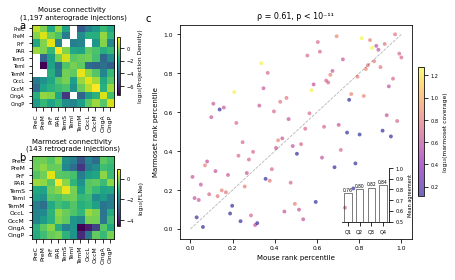

In [7]:
mm_to_inch = 1 / 25.4
fig_w = 210 * mm_to_inch  
fig_h = 100 * mm_to_inch   

label_fontsize=6

fig = plt.figure(figsize=(fig_w, fig_h))

import matplotlib.gridspec as gridspec

gs = gridspec.GridSpec(2, 2, figure=fig,
                       width_ratios=[1, 2],
                       hspace=0.6, wspace=0.2)

# Short labels for heatmaps — in CORTICAL order
short_labels = {
    "FRO_Precentral": "PreC", "FRO_Premotor": "PreM",
    "FRO_Prefrontal": "PrF",
    "PAR": "PAR",
    "TEM_Superior": "TemS", "TEM_Inferior": "TemI",
    "TEM_Medial": "TemM",
    "OCC_Lateral": "OccL", "OCC_Medial": "OccM",
    "CIN_Anterior": "CingA", "CIN_Posterior": "CingP",
}
labels = [short_labels.get(r, r) for r in cortical_ordered]

# Mouse heatmap (log scale for visibility)
ax_m = fig.add_subplot(gs[0, 0])
m_vals = M.values.copy()
m_vals[m_vals == 0] = np.nan
im_m = ax_m.imshow(np.log10(m_vals), cmap="viridis", aspect="equal",
                    interpolation="nearest")
ax_m.set_xticks(range(len(labels)))
ax_m.set_yticks(range(len(labels)))
ax_m.set_xticklabels(labels, rotation=90, fontsize=label_fontsize)
ax_m.set_yticklabels(labels, fontsize=5)
ax_m.set_title("Mouse connectivity \n(1,197 anterograde injections)", fontsize=7, fontweight="normal")
cb_m = plt.colorbar(im_m, ax=ax_m, shrink=0.7, pad=0.02)
cb_m.set_label("log₁₀(Projection Density)", fontsize=label_fontsize)
cb_m.ax.tick_params(labelsize=5)

# Marmoset heatmap (log scale)
ax_f = fig.add_subplot(gs[1, 0])
f_vals = F.values.copy()
f_vals[f_vals == 0] = np.nan
im_f = ax_f.imshow(np.log10(f_vals), cmap="viridis", aspect="equal",
                    interpolation="nearest")
ax_f.set_xticks(range(len(labels)))
ax_f.set_yticks(range(len(labels)))
ax_f.set_xticklabels(labels, rotation=90, fontsize=label_fontsize)
ax_f.set_yticklabels(labels, fontsize=label_fontsize)
ax_f.set_title("Marmoset connectivity \n(143 retrograde injections)", fontsize=7, fontweight="normal")
cb_f = plt.colorbar(im_f, ax=ax_f, shrink=0.7, pad=0.02)
cb_f.set_label("log₁₀(FLNe)", fontsize=label_fontsize)
cb_f.ax.tick_params(labelsize=5)

# Scatter (spans both rows)
ax_sc = fig.add_subplot(gs[:, 1])
ax_sc.set_aspect('auto')
sc = ax_sc.scatter(df["mouse_rank_pct"], df["marmoset_rank_pct"],
                   alpha=0.6, s=15,
                   c=np.log10(df["marmoset_signal_min"].clip(lower=1e-3)),
                   cmap="plasma", edgecolors="none")
ax_sc.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=0.8)
ax_sc.set_xlabel("Mouse rank percentile", fontsize=7)
ax_sc.set_ylabel("Marmoset rank percentile", fontsize=7)
ax_sc.set_title(f"ρ = {rho_all:.2f}, p < 10⁻¹¹", fontsize=8, fontweight="normal")
ax_sc.set_xlim(-0.05, 1.05)
ax_sc.set_ylim(-0.05, 1.05)
ax_sc.tick_params(labelsize=6)
cbar = plt.colorbar(sc, ax=ax_sc, shrink=0.6, pad=0.02)
cbar.set_label("log₁₀(marmoset coverage)", fontsize=label_fontsize)
cbar.ax.tick_params(labelsize=5)

# === INSET: quartile mean agreement bars ===
#ax_inset = ax_sc.inset_axes([0.55, 0.05, 0.42, 0.32])
ax_inset = ax_sc.inset_axes([0.7, 0.08, 0.20, 0.25])

quartile_order = ["Q1 (sparse)", "Q2", "Q3", "Q4 (dense)"]
quartile_means = []
quartile_ns = []
for q in quartile_order:
    sub = df[df["coverage_quartile"] == q]
    quartile_means.append(sub["agreement"].mean())
    quartile_ns.append(len(sub))

#colors = ["#440154", "#31688e", "#35b779", "#fde725"]
bars = ax_inset.bar(range(4), quartile_means, facecolor="none",
                     edgecolor="black", linewidth=0.5, width=0.65)
ax_inset.set_xticks(range(4))
ax_inset.set_xticklabels(["Q1", "Q2", "Q3", "Q4"], fontsize=5)
ax_inset.set_ylabel("Mean agreement", fontsize=5)
ax_inset.set_ylim(0.5, 1.0)
ax_inset.set_facecolor("none")      # transparent background
ax_inset.patch.set_alpha(0.0)       # ensure full transparency

ax_inset.tick_params(labelsize=5)
#ax_inset.set_title("Mean agreement", fontsize=label_fontsize, pad=2)
for i, (v, n) in enumerate(zip(quartile_means, quartile_ns)):
    ax_inset.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=4.5)
    ax_inset.text(i, 0.03, f"n={n}", ha="center", fontsize=4, color="white")
ax_inset.spines["top"].set_visible(False)
ax_inset.spines["right"].set_visible(False)
ax_inset.yaxis.tick_right()
ax_inset.yaxis.set_label_position("right")
ax_inset.spines["right"].set_position(("axes", 1.0))
ax_inset.spines["right"].set_visible(True)
ax_inset.spines["left"].set_visible(False)


# Panel labels
for ax, label in zip([ax_m, ax_f, ax_sc], ["a", "b", "c"]):
    ax.text(-0.15, 1.05, label, transform=ax.transAxes,
            fontsize=10, fontweight="normal", va="top")

#plt.savefig(f"{OUT_DIR}/fig_tracer_validation.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUT_DIR}/fig_tracer_validation.svg")
#print(f"\nFigure saved: fig_tracer_validation.png/pdf")

df.to_csv(f"{OUT_DIR}/weighted_agreement_pairs.csv", index=False)
